# Day 48 (1/2) — Decision Tree Classification

### The idea in one sentence
> A decision tree is a **flowchart of yes/no questions** learned from the data:
> *"Is Age ≤ 44.5?" → "Is Salary ≤ 90,500?" → "Buys."*

It is the model closest to how humans make decisions, and you can **read** exactly why it predicted something.

### The problem (same as Days 45–47)
Predict whether a social-network user **buys an SUV** from **Age** and **Estimated Salary**.

### In this notebook
1. Train a tree (no scaling needed!) and evaluate it
2. **Read the tree**: the actual questions it learned
3. See the **boxy** decision boundary
4. Overfitting: the full tree memorises; `max_depth` fixes it
5. Tune the tree with cross-validation
6. Feature importance

> 📖 Theory: [`theory.md`](theory.md) · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#FA8072', '#1E90FF']          # 0 = did not buy (salmon), 1 = bought (blue)
CMAP = ListedColormap(COLORS)

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values      # Age, EstimatedSalary
y = dataset.iloc[:, -1].values       # Purchased (0 / 1)
print(dataset.shape)
dataset.head()

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


> ✍️ **Core code: learn this.** 75% train, 25% test.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape)

(300, 2) (100, 2)


### No feature scaling?
A tree only asks questions like *"Is Age ≤ 44.5?"*, comparing **one feature at a time with a threshold**. It never
computes distances or adds features together, so scaling changes nothing (we prove this in Section 7). Bonus: the
rules stay in real units (years, salary) and are easy to read.

## 1. Train the decision tree

> ✍️ **Core code: learn this.** `criterion='entropy'` measures how mixed a group is (theory §3).

In [4]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

print("Depth of the tree:", classifier.get_depth())
print("Number of leaves :", classifier.get_n_leaves())

Depth of the tree: 12
Number of leaves : 50


## 2. Predict a new customer

In [5]:
print("Age 30, salary 87,000  ->", classifier.predict([[30, 87000]])[0])
print("Age 50, salary 120,000 ->", classifier.predict([[50, 120000]])[0])

Age 30, salary 87,000  -> 0
Age 50, salary 120,000 -> 1


## 3. Evaluate

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test)

print("Training accuracy:", accuracy_score(y_train, classifier.predict(X_train)))
print("Test accuracy    :", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, target_names=['did not buy', 'bought']))

Training accuracy: 1.0
Test accuracy    : 0.91

Confusion matrix:
 [[62  6]
 [ 3 29]]

               precision    recall  f1-score   support

 did not buy       0.95      0.91      0.93        68
      bought       0.83      0.91      0.87        32

    accuracy                           0.91       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



**Training accuracy 100%, test accuracy 91%.** The tree grew **12 levels deep with 50 leaves**: it kept splitting
until every training point was classified perfectly, including the noisy ones. That is **overfitting**.

## 4. Read the tree

A 50-leaf tree is unreadable. Let's train a small tree, only **2 questions deep**, and print its rules.

> ✍️ **Core code: learn this.** `max_depth` limits how many questions the tree can ask in a row; `export_text` prints the rules.

In [7]:
from sklearn.tree import export_text

small_tree = DecisionTreeClassifier(max_depth=2, random_state=0)
small_tree.fit(X_train, y_train)

print(export_text(small_tree, feature_names=['Age', 'EstimatedSalary']))
print("Test accuracy of this 2-level tree:", accuracy_score(y_test, small_tree.predict(X_test)))

|--- Age <= 44.50
|   |--- EstimatedSalary <= 90500.00
|   |   |--- class: 0
|   |--- EstimatedSalary >  90500.00
|   |   |--- class: 1
|--- Age >  44.50
|   |--- Age <= 46.50
|   |   |--- class: 1
|   |--- Age >  46.50
|   |   |--- class: 1

Test accuracy of this 2-level tree: 0.94


In plain English:
1. **Younger than 44.5?** Buys only if the salary is **above 90,500**.
2. **44.5 or older?** Buys.

(The tree splits the older group once more, at 46.5, but both branches say "buys"; it does that because the split makes
the groups purer, even though the final answer is the same.)

This 2-question tree scores **0.94** on the test set, **better** than the 50-leaf tree. Simpler often generalises better.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

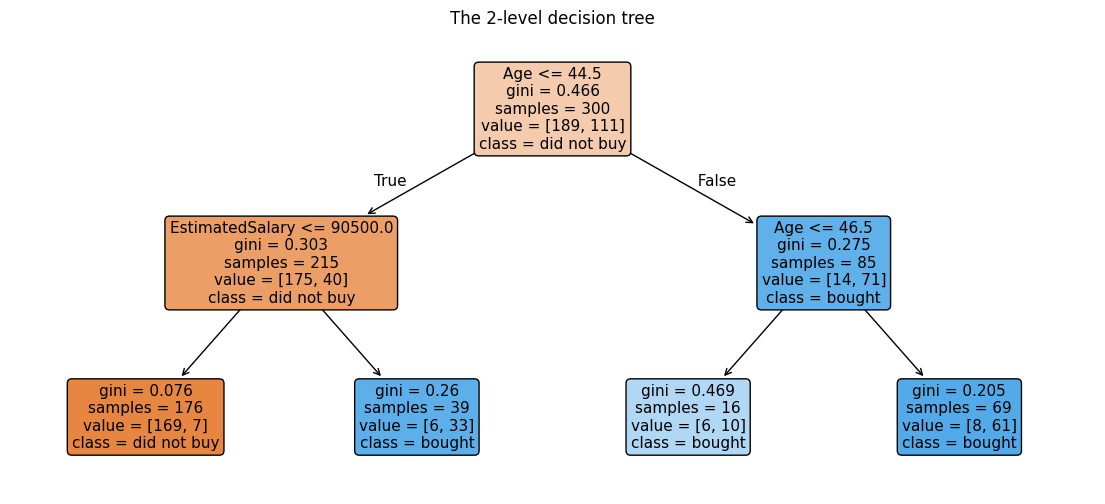

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 6))
plot_tree(small_tree, feature_names=['Age', 'EstimatedSalary'], class_names=['did not buy', 'bought'],
          filled=True, rounded=True, fontsize=11)
plt.title('The 2-level decision tree')
plt.show()

Each box shows the **question**, the **gini** impurity (0 = pure), how many training **samples** reach it,
the class counts (**value**), and the majority **class**. Colour intensity = how pure the box is.

## 5. The decision boundary: boxes, not curves

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

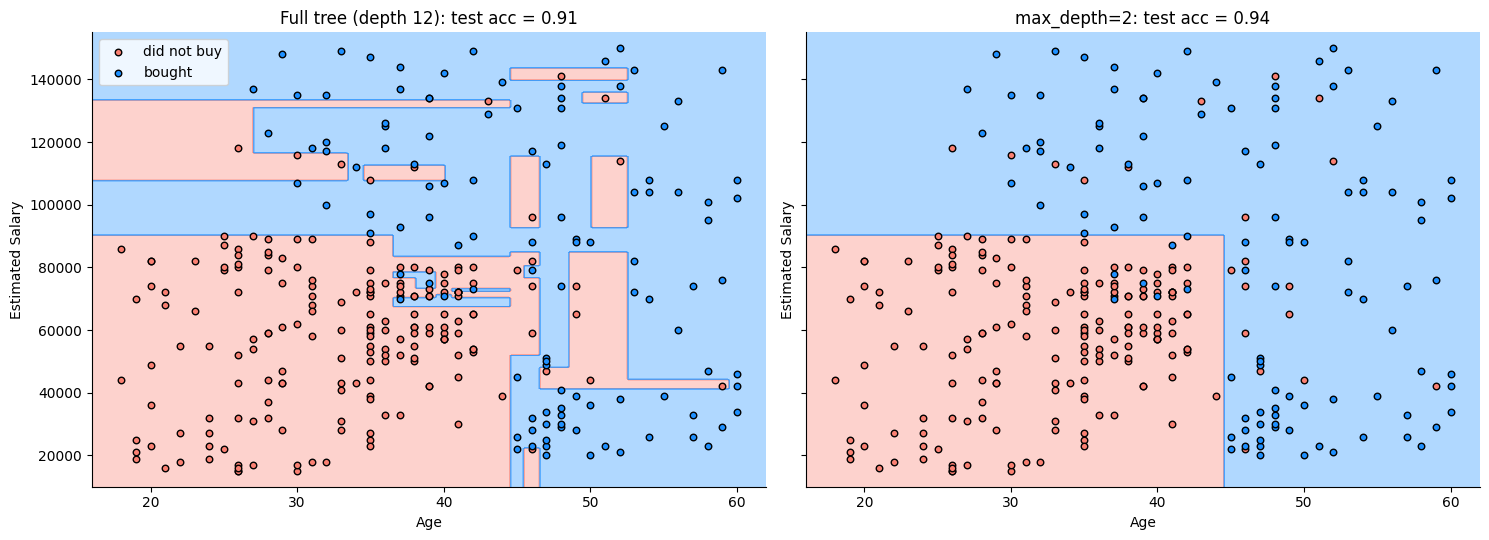

In [9]:
def plot_boundary(ax, model, X_raw, y, title=''):
    # Colour every point of a grid by the model's prediction, then draw the real points on top.
    a = np.linspace(X_raw[:, 0].min() - 2, X_raw[:, 0].max() + 2, 300)
    s = np.linspace(X_raw[:, 1].min() - 5000, X_raw[:, 1].max() + 5000, 300)
    A, S = np.meshgrid(a, s)
    Z = model.predict(np.c_[A.ravel(), S.ravel()]).reshape(A.shape)
    ax.contourf(A, S, Z, alpha=0.35, cmap=CMAP)
    for label in [0, 1]:
        ax.scatter(X_raw[y == label, 0], X_raw[y == label, 1], color=COLORS[label], edgecolor='k',
                   s=22, label=['did not buy', 'bought'][label])
    ax.set_xlabel('Age')
    ax.set_ylabel('Estimated Salary')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_boundary(axes[0], classifier, X_train, y_train,
              f'Full tree (depth {classifier.get_depth()}): test acc = {accuracy_score(y_test, classifier.predict(X_test)):.2f}')
plot_boundary(axes[1], small_tree, X_train, y_train,
              f'max_depth=2: test acc = {accuracy_score(y_test, small_tree.predict(X_test)):.2f}')
axes[0].legend()
plt.tight_layout()
plt.show()

Every split is a **horizontal or vertical cut**, so a tree's regions are always **rectangles**.
- **Left:** the full tree carves tiny boxes around individual training points: memorising noise.
- **Right:** two cuts capture the real pattern.

## 6. Finding the right depth

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

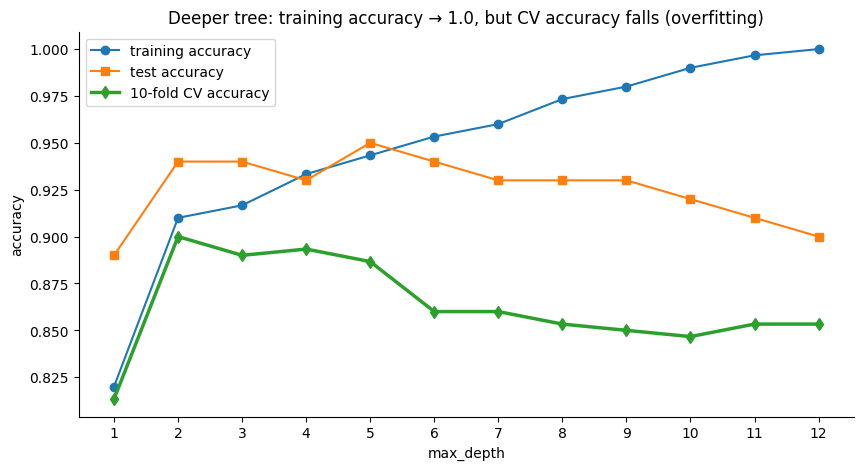

In [10]:
from sklearn.model_selection import cross_val_score

depths = list(range(1, 13))
train_acc, test_acc, cv_acc = [], [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))
    cv_acc.append(cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=0), X_train, y_train, cv=10).mean())

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, 'o-', label='training accuracy')
plt.plot(depths, test_acc, 's-', label='test accuracy')
plt.plot(depths, cv_acc, 'd-', linewidth=2.5, label='10-fold CV accuracy')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(depths)
plt.title('Deeper tree: training accuracy → 1.0, but CV accuracy falls (overfitting)')
plt.legend()
plt.show()

Training accuracy climbs to 1.0 as the tree gets deeper, but cross-validation accuracy **peaks early** and then
drops. That gap is overfitting.

The main ways to stop a tree growing too much (**pre-pruning**):

| Parameter | Meaning |
|---|---|
| `max_depth` | maximum number of questions in a row |
| `min_samples_leaf` | every leaf must contain at least this many training points |
| `min_samples_split` | a node needs at least this many points to be split further |
| `max_leaf_nodes` | maximum number of leaves |

> ✍️ **Core code: learn this.** Let cross-validation pick the settings.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
}
search = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=10)
search.fit(X_train, y_train)

print("Best parameters :", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 3))
print("Test accuracy   :", search.score(X_test, y_test))

Best parameters : {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10}
Best CV accuracy: 0.907
Test accuracy   : 0.94


## 7. Proof: scaling makes no difference

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler().fit(X_train)
scaled_tree = DecisionTreeClassifier(criterion='entropy', random_state=0).fit(sc.transform(X_train), y_train)

same = (scaled_tree.predict(sc.transform(X_test)) == classifier.predict(X_test)).all()
print("Identical predictions with and without scaling:", same)

Identical predictions with and without scaling: True


## 8. Feature importance

> ✍️ **Core code: learn this.** How much each feature reduced impurity across all splits (sums to 1).

In [13]:
best_tree = search.best_estimator_
pd.Series(best_tree.feature_importances_, index=['Age', 'EstimatedSalary']).round(3)

Age                0.55
EstimatedSalary    0.45
dtype: float64

Age is slightly more important than salary for the tuned tree (about 0.55 vs 0.45); both are used.

---
## Key takeaways
- A decision tree learns a **flowchart of yes/no questions**, choosing each split to make the groups as **pure** as possible.
- It is **readable**: you can print or draw the exact rules.
- **No scaling** needed; boundaries are made of **rectangles**.
- An unrestricted tree **overfits** (training 100%, test 91% here). Limit it with `max_depth` / `min_samples_leaf`,
  chosen by cross-validation (tuned test accuracy: 0.94).

## 🧠 Quick check

<details><summary>1. Why doesn't a decision tree need feature scaling?</summary>

Each split compares one feature with a threshold; no distances or sums of features are involved.
</details>

<details><summary>2. Training accuracy 100%, test 91%. What is happening, and how do you fix it?</summary>

Overfitting: the tree memorised the training data. Limit its growth with `max_depth`, `min_samples_leaf`, etc., tuned by cross-validation.
</details>

<details><summary>3. Why are the decision regions always rectangles?</summary>

Every split is a single-feature threshold, which is a vertical or horizontal cut.
</details>

➡️ **Next:** `02-decision-tree-regression.ipynb`: the same tree, predicting numbers.